In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/dataset ml.csv")
print(f"Dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()

Dataset : 4372 lignes × 52 colonnes


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


In [2]:
# Valeurs manquantes
df.isnull().sum()[df.isnull().sum() > 0]

AvgDaysBetweenPurchases      79
Age                        1311
dtype: int64

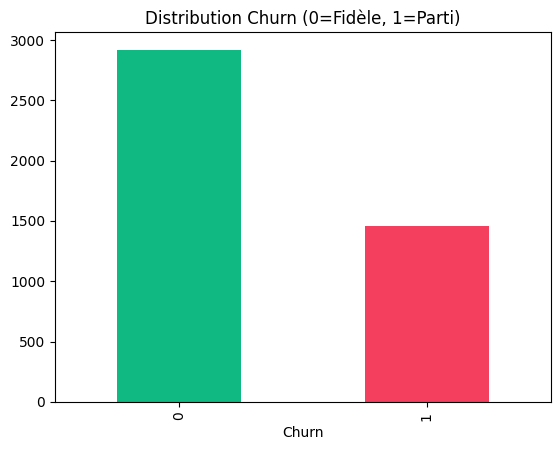

Taux de churn : 33.3%


In [3]:
# Distribution Churn
df['Churn'].value_counts().plot(kind='bar', color=['#10b981','#f43f5e'])
plt.title("Distribution Churn (0=Fidèle, 1=Parti)")
plt.show()
print(f"Taux de churn : {df['Churn'].mean()*100:.1f}%")

In [4]:
# Corrélations avec Churn — détection du leakage
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corrwith(df['Churn']).abs().sort_values(ascending=False)
print("TOP 15 corrélations avec Churn :")
print(corr.head(15).round(4))

TOP 15 corrélations avec Churn :
Churn                    1.0000
Recency                  0.8590
CustomerTenureDays       0.4535
PreferredMonth           0.4309
UniqueDescriptions       0.2698
UniqueProducts           0.2698
Frequency                0.2226
UniqueInvoices           0.2226
FirstPurchaseDaysAgo     0.2216
TotalTransactions        0.1817
NegativeQuantityCount    0.1290
CancelledTransactions    0.1290
TotalQuantity            0.1170
MonetaryTotal            0.1136
AvgLinesPerInvoice       0.1047
dtype: float64


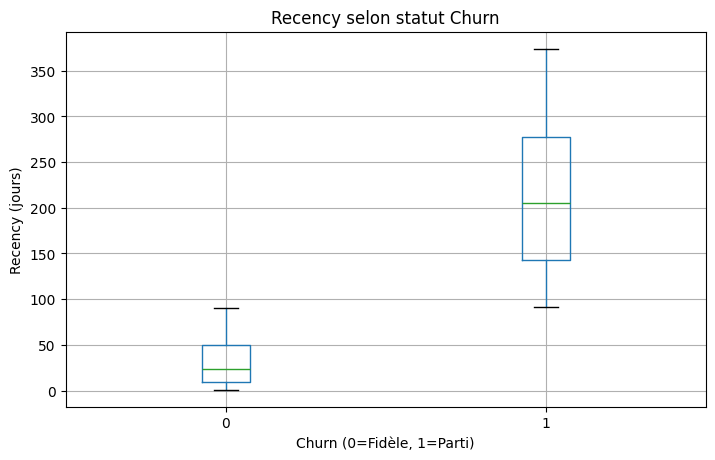

In [5]:
# Preuve visuelle du leakage Recency
df.boxplot(column='Recency', by='Churn', figsize=(8,5))
plt.title("Recency selon statut Churn")
plt.suptitle("")
plt.xlabel("Churn (0=Fidèle, 1=Parti)")
plt.ylabel("Recency (jours)")
plt.show()
# Conclusion : Recency = leakage, corrélation 0.859

In [6]:
# Valeurs sentinelles détectées
print("SupportTicketsCount :", df['SupportTicketsCount'].value_counts().head(5).to_dict())
print("SatisfactionScore   :", df['SatisfactionScore'].value_counts().head(5).to_dict())
# → Détection de -1, 999, 99

SupportTicketsCount : {2.0: 1183, 1.0: 1140, 3.0: 753, 0.0: 596, 4.0: 365}
SatisfactionScore   : {5.0: 847, 1.0: 824, 3.0: 789, 4.0: 786, 2.0: 777}


In [7]:
# Distribution des colonnes catégorielles importantes
for col in ['RFMSegment', 'CustomerType', 'LoyaltyLevel', 'ChurnRiskCategory']:
    print(f"\n{col} :")
    print(df[col].value_counts())


RFMSegment :
RFMSegment
Potentiels    1589
Fidèles       1177
Champions      979
Dormants       627
Name: count, dtype: int64

CustomerType :
CustomerType
Occasionnel    1198
Nouveau        1157
Perdu           864
Régulier        703
Hyperactif      450
Name: count, dtype: int64

LoyaltyLevel :
LoyaltyLevel
Nouveau    1714
Établi     1588
Jeune       970
Ancien      100
Name: count, dtype: int64

ChurnRiskCategory :
ChurnRiskCategory
Faible      1695
Critique    1454
Moyen        743
Élevé        480
Name: count, dtype: int64
